In [1]:
import pandas

In [ ]:
df1 = pandas.read_csv("/data/wenjing/skin_dataset/ssl/ssl_data/HAM.csv")

In [ ]:
df1 = df1.rename(columns={"isic_id": "image_id"})
df1.to_csv("HAM.csv", index=False)

        isic_id                                        attribution  \
0  ISIC_0024306  ViDIR Group, Department of Dermatology, Medica...   
1  ISIC_0024307  ViDIR Group, Department of Dermatology, Medica...   

  copyright_license  age_approx anatom_site_general anatom_site_special  \
0          CC-BY-NC        45.0                 NaN                 NaN   
1          CC-BY-NC        50.0     lower extremity                 NaN   

   concomitant_biopsy diagnosis_1                        diagnosis_2  \
0               False      Benign  Benign melanocytic proliferations   
1               False      Benign  Benign melanocytic proliferations   

  diagnosis_3            diagnosis_confirm_type   image_type   lesion_id  \
0       Nevus  serial imaging showing no change  dermoscopic  IL_7252831   
1       Nevus  serial imaging showing no change  dermoscopic  IL_6125741   

   melanocytic   sex  dx  
0         True  male  nv  
1         True  male  nv  


In [1]:
c = (1,)
print(c)
d = tuple(c)
print(d)

(1,)
(1,)


In [5]:
from torch import tensor
from torchmetrics.classification import MulticlassF1Score
target = tensor([2, 1, 0, 0])
preds = tensor([[0.16, 0.26, 0.58],
        [0.2, 0.6, 0.12],
        [0.87, 0.19, 0.20],
        [0.25, 0.82, 0.03]])
metric = MulticlassF1Score(num_classes=3, average='weighted')
metric(preds, target)

tensor(0.7500)

In [ ]:
st = "a:sdf=abc"
a = st.replace(":", "=").split("=")[0]
b = st.replace(":", "=").split("=")[1]
print(st, a, b)

a:sdf=abc a sdf


In [ ]:
a = set(["best"])
if "best" in a:
    print("yes")

AUPR: 0.4566570818424225


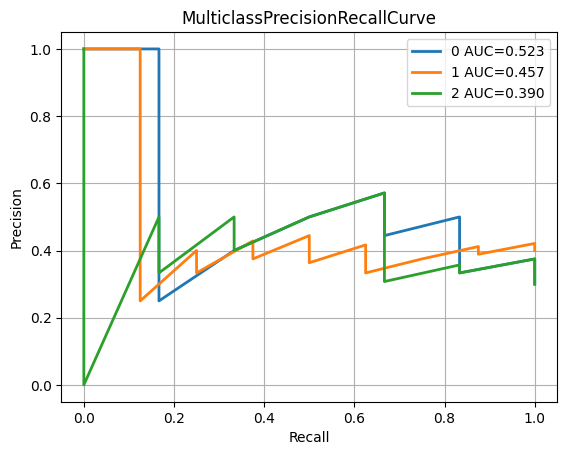

In [1]:
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassAUROC,
    MulticlassF1Score,
    MulticlassPrecisionRecallCurve,
)
import torch
from torch import randn, randint
from torchmetrics.functional.classification.auroc import _reduce_auroc

def compute_AUPR(self, curve=None):
    """Return AUPR and do not plot the curve figure."""
    curve_computed = curve or self.compute()
    # switch order as the standard way is recall along x-axis and precision along y-axis
    curve_computed = (curve_computed[1], curve_computed[0], curve_computed[2])
    score = (
        _reduce_auroc(curve_computed[0], curve_computed[1], average=None, direction=-1.0)
        )
    return score.mean()
MulticlassPrecisionRecallCurve.compute_AUPR = compute_AUPR

preds = randn(20, 3)
target = randint(3, (20,))
metric = MulticlassPrecisionRecallCurve(num_classes=3)
metric.update(preds, target)
f, a = metric.plot(score=True)
AUPR = metric.compute_AUPR(curve=None)
print(f"AUPR: {AUPR}")

In [10]:
import torch
import torch.nn as nn
# Image Example
N, C, D = 2, 3, 3
input = torch.randint(0, 10, (2, 3, 3)).float()
print(input)
# Normalize over the last three dimensions (i.e. the channel and spatial dimensions)
# as shown in the image below
layer_norm = nn.LayerNorm(D)
output = layer_norm(input)
print(output)

tensor([[[3., 9., 7.],
         [8., 8., 9.],
         [0., 3., 3.]],

        [[6., 1., 2.],
         [8., 9., 2.],
         [2., 3., 0.]]])
tensor([[[-1.3363,  1.0690,  0.2673],
         [-0.7071, -0.7071,  1.4142],
         [-1.4142,  0.7071,  0.7071]],

        [[ 1.3887, -0.9258, -0.4629],
         [ 0.5392,  0.8627, -1.4018],
         [ 0.2673,  1.0690, -1.3363]]], grad_fn=<NativeLayerNormBackward0>)


In [1]:
a = [1, 2]
c, d = a
print(c, d)

1 2


In [2]:
x = [1,2]
m = [5]
for it_x, it_m in zip(x, m):
    print(it_x, it_m)

1 5


In [2]:
import torch.nn as nn

class test(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x, y):
        x = x + 1
        y = y + 2
        return x, y
    
t = test()
a, b = t(1, 2)
print(a, b)

2 4


In [2]:
from multiprocessing import cpu_count
print(cpu_count())

80


In [6]:
import torch
x = torch.arange(12).reshape(3,4)
print(x)
# tensor([[0, 1, 2, 3],
#         [4, 5, 6, 7],
#         [8, 9,10,11]])

y = x.transpose(0,1)
print(y)
print(y.is_contiguous())  # False

z = y.contiguous().view(4, 3)
print(z)
# tensor([0, 4, 8, 1, 5, 9, 2, 6,10, 3, 7,11])


tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]])
False
tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]])


In [3]:
import torch
import torch.nn.functional as F
a = torch.zeros((2,2))
a_n = F.normalize(a)
print(a_n)

tensor([[0., 0.],
        [0., 0.]])


In [3]:
import numpy as np
import torch
from torchvision import transforms
toTensor = transforms.Compose(
    [
        transforms.ToTensor(),
        # make_normalize_transform(mean=mean, std=std),
    ]
)
a = np.array([[1,2,3],[4,5,6]])
print(a.dtype)
a_t = toTensor(a)
print(a_t)

RuntimeError: duplicate registrations for aten.linspace.Tensor_Tensor

In [14]:
import torch
x = torch.arange(96).reshape(4*2,3,2,2) # B, C, N, H, W stride(12, 4, 1)
y = x.unflatten(0, (2, 4)) #  B N C H W stride(1, 12, 4)
print(y)  
# print(y)  # (4, 2, 3)
# print(y.reshape(3, -1))
#print(x[0][0][1])
#print(y[0][0][1])


tensor([[[[[ 0,  1],
           [ 2,  3]],

          [[ 4,  5],
           [ 6,  7]],

          [[ 8,  9],
           [10, 11]]],


         [[[12, 13],
           [14, 15]],

          [[16, 17],
           [18, 19]],

          [[20, 21],
           [22, 23]]],


         [[[24, 25],
           [26, 27]],

          [[28, 29],
           [30, 31]],

          [[32, 33],
           [34, 35]]],


         [[[36, 37],
           [38, 39]],

          [[40, 41],
           [42, 43]],

          [[44, 45],
           [46, 47]]]],



        [[[[48, 49],
           [50, 51]],

          [[52, 53],
           [54, 55]],

          [[56, 57],
           [58, 59]]],


         [[[60, 61],
           [62, 63]],

          [[64, 65],
           [66, 67]],

          [[68, 69],
           [70, 71]]],


         [[[72, 73],
           [74, 75]],

          [[76, 77],
           [78, 79]],

          [[80, 81],
           [82, 83]]],


         [[[84, 85],
           [86, 87]],

          [[88, 

In [ ]:
import torch
import torch.nn.functional as F
x = torch.zeros(3,8,8)  # [1, 2, 3, 4, 5, 6, 7]
y = torch.randn(3,8,8)
# ===== 切分成16×16 patch =====
def img_to_patches(x, patch_size=16):
    C, H, W = x.shape
    x = x.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size) # [C, num_patches_h, num_patches_w, h, w]
    x = x.contiguous().view(C, -1, patch_size, patch_size)  # [C,num_patches,h,w]
    return x

patches1 = img_to_patches(x, 2)
patches2 = img_to_patches(y, 2)

C, N, H, W = patches1.shape
num_patches_side = int(8 / 2)

# ===== 计算patch特征并余弦相似度 =====
patches1_flat = patches1.permute(1,0,2,3).reshape(N, -1)
patches2_flat = patches2.permute(1,0,2,3).reshape(N, -1)
patches1_flat = F.normalize(patches1_flat, dim=1) # l2 norm
patches2_flat = F.normalize(patches2_flat, dim=1)

# 相似度矩阵: [N1, N2]
sim_matrix = patches1_flat @ patches2_flat.T  # [N, N]
sim = sim_matrix[3].reshape(num_patches_side, num_patches_side)
print(sim)
if sim.min() == sim.max():
    sim_norm = torch.zeros_like(sim)
else:
    sim_norm = (sim - sim.min()) / (sim.max() - sim.min())
sim_np = sim_norm.numpy().flatten()
print(sim_np)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]


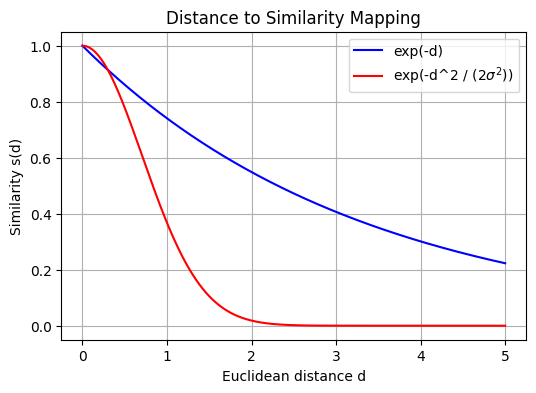

In [7]:
import torch
import matplotlib.pyplot as plt

# 距离范围
d = torch.linspace(0, 5, 500)

# 计算两种函数
s1 = torch.exp(-0.3* d)
sigma = 1.0
s2 = torch.exp(- (d**2) / (sigma**2))

# 绘图
plt.figure(figsize=(6,4))
plt.plot(d, s1, label=r'exp(-d)', color='blue')
plt.plot(d, s2, label=r'exp(-d^2 / (2$\sigma^2$))', color='red')
plt.xlabel("Euclidean distance d")
plt.ylabel("Similarity s(d)")
plt.title("Distance to Similarity Mapping")
plt.grid(True)
plt.legend()
plt.show()


In [12]:
a = [s[i] for i in range(2) for s in [{0:"img0_crop0", 1:"img0_crop1"}, {0:"img1_crop0", 1:"img1_crop1"}, {0:"img2_crop0", 1:"img2_crop1"}]]
print(a)

['img0_crop0', 'img1_crop0', 'img2_crop0', 'img0_crop1', 'img1_crop1', 'img2_crop1']


In [20]:
import torch
import torch.nn.functional as F
# torch.manual_seed(6)

student_feats = torch.randn(4,2,2)
teacher_feats = torch.randn(4,2,2)

student_feats = F.normalize(student_feats, dim=-1)  # [2*B, N, D]
teacher_feats = F.normalize(teacher_feats, dim=-1)  # [2*B, N, D]

pcr_bin_matrix = torch.randint(0, 2, [2,2,2])
# bi here represents 2 directions v->u & u->v 
B = teacher_feats.shape[0] // 2
teacher_feats_reorder = torch.cat([teacher_feats[B:], teacher_feats[:B]])
sim_matrix_s_t = torch.exp(torch.matmul(student_feats, teacher_feats_reorder.transpose(-1,-2)) / 0.1)
bi_bin_matrix = torch.cat([pcr_bin_matrix, pcr_bin_matrix.transpose(-1,-2)], dim=0)  # [2*B, N, N]
bi_positive_set = bi_bin_matrix * sim_matrix_s_t  # [2*B, N, N]

valid_rows = (bi_positive_set.sum(dim=-1) > 0) & (bi_bin_matrix.sum(dim=-1) < bi_bin_matrix.shape[-1])
valid_cols = (bi_positive_set.sum(dim=-2) > 0) & (bi_bin_matrix.sum(dim=-2) < bi_bin_matrix.shape[-2])

valid_row_vals = torch.log((bi_positive_set.sum(dim=-1)) / (sim_matrix_s_t.sum(dim=-1) + 1e-8))[valid_rows]
valid_col_vals = torch.log((bi_positive_set.sum(dim=-2)) / (sim_matrix_s_t.sum(dim=-2) + 1e-8))[valid_cols]

loss_bi_ij = -(valid_row_vals.mean() if valid_row_vals.numel() > 0 else torch.tensor(0.0))
loss_bi_ji = -(valid_col_vals.mean() if valid_col_vals.numel() > 0 else torch.tensor(0.0))

loss = 0.5 * (loss_bi_ij + loss_bi_ji)
pass

KeyboardInterrupt: 

In [5]:
import numpy as np

a = np.random.randint(0,5,(2,2,3))
print(a**2)
print((a**2).sum(axis=(0,1)))

[[[ 4  0  9]
  [16  1  1]]

 [[ 9  4  1]
  [ 1  4 16]]]
[30  9 27]


In [6]:
import torch.nn as nn
import torch
loss = nn.MSELoss()
input = torch.randint(0,4,(3, 2, 2)).float()
target = torch.randint(0,4,(3, 2, 2)).float()
output = loss(input, target)
print(input)
print(input.mean())
print(target)
print(output)

tensor([[[0., 1.],
         [0., 3.]],

        [[2., 1.],
         [0., 0.]],

        [[3., 0.],
         [1., 2.]]])
tensor(1.0833)
tensor([[[0., 0.],
         [3., 2.]],

        [[0., 2.],
         [2., 3.]],

        [[1., 2.],
         [3., 3.]]])
tensor(3.5000)


In [3]:
import torch
pos_mask = torch.randint(0,2,(4,2,2))
pos_indices = pos_mask.nonzero(as_tuple=False)
print(pos_mask)
print(pos_indices)
print(torch.arange(10))

tensor([[[0, 0],
         [0, 1]],

        [[1, 0],
         [1, 0]],

        [[1, 1],
         [1, 0]],

        [[0, 1],
         [0, 0]]])
tensor([[0, 1, 1],
        [1, 0, 0],
        [1, 1, 0],
        [2, 0, 0],
        [2, 0, 1],
        [2, 1, 0],
        [3, 0, 1]])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [9]:
import torch
import torch.nn.functional as F

def patch_infonce_ce(sim_matrix_s2t, pos_mask, temperature=0.1):
    logits = sim_matrix_s2t / temperature
    pos_indices = pos_mask.nonzero(as_tuple=False)
    if pos_indices.numel() == 0:
        return torch.tensor(0., device=logits.device)

    b_idx = pos_indices[:, 0]
    i_idx = pos_indices[:, 1]
    j_pos = pos_indices[:, 2]

    P = len(j_pos)
    _, N, _ = logits.shape

    logits_expanded = logits[b_idx, i_idx, :]
    all_pos_mask = pos_mask[b_idx, i_idx, :]

    mask_without_self = all_pos_mask.clone()
    mask_without_self[torch.arange(P), j_pos] = False

    logits_expanded = logits_expanded.masked_fill(mask_without_self, float('-inf'))
    target_expanded = j_pos

    loss = F.cross_entropy(logits_expanded, target_expanded)
    return loss, logits_expanded, target_expanded

# Example data
torch.manual_seed(0)
B = 2

# random similarity
sim = torch.randint(1,3, (2*B, 3, 3))

# pos mask: let's define some positives
pos_mask = torch.zeros_like(sim, dtype=torch.bool)
pos_mask[1, 2, 1] = True
pos_mask[2, 2, 0] = True
pos_mask[2, 2, 1] = True
loss, logits_expanded, target_expanded = patch_infonce_ce(sim, pos_mask)
# sim, pos_mask,
loss, logits_expanded, target_expanded


(tensor(3.9306),
 tensor([[10., 10., 10.],
         [10., -inf, 20.],
         [-inf, 20., 20.]]),
 tensor([1, 0, 1]))

In [3]:
from torchmetrics.classification import  MulticlassAccuracy
import torch
metric = MulticlassAccuracy(num_classes=3, average="macro")
preds = torch.tensor([[0.16, 0.26, 0.58],
                      [0.22, 0.61, 0.17],
                      [0.71, 0.09, 0.20],
                      [0.05, 0.82, 0.13]])
target = torch.tensor([2,1,0,0])
a = metric(preds, target)
a


tensor(0.8333)

In [6]:
class cat():
    leg: int
    def __init__(self, sound="Meow", color="black"):
        self.sound = sound
        self.color = color
c = cat(leg=4)
c.size = "small"
print(c.leg)

TypeError: cat.__init__() got an unexpected keyword argument 'leg'

In [3]:
def f(flag):
    if flag:
        return 1, "yes"
    else:
        return 0, "no"
a, b = f(False)
print(a, b)

0 no


In [5]:
from typing import Tuple, TypedDict
import torch
class BaseModelContext(TypedDict):
    """
    An object that contains the context of a model (autocast, description, ...)
    """

    autocast_dtype: torch.dtype  # default could be torch.float

test_context = BaseModelContext(autocast_dtype=torch.float32)
print(test_context["autocast_dtype"])

torch.float32


In [8]:
import torch

a = torch.randn(2,3,4)
b = a[:,0]
print(b.shape)

torch.Size([2, 4])


In [ ]:
dic = {"HAM10K:split=TEST:root=/data/wenjing/skin_dataset/ssl:extra=/data/wenjing/skin_dataset/ssl/extra_accuracy":86,
       "best_classifier": "classifier_1_blocks_avgpool_True_lr_0_20000",
       "HAM10K:split=VAL:root=/data/wenjing/skin_dataset/ssl:extra=/data/wenjing/skin_dataset/ssl/extra_accuracy": 88,
       }
print()

KeyError: 0

In [3]:
import pandas as pd

meta_df = pd.read_csv("/data/wenjing/skin_dataset/ssl/ssl_data/HIBA.csv")
meta_df = meta_df[meta_df['image_type'] == 'dermoscopic'].copy()
meta_df = meta_df[meta_df['dx'].notna() & (meta_df['dx'].astype(str).str.strip() != '')].copy()
print(meta_df.shape)

(1234, 20)


In [8]:
import pandas as pd

# 读取 CSV
msk_label = pd.read_csv("/data/wenjing/skin_dataset/ssl/ssl_data/HIBA.csv")

# 提取 isic_id 列（转成集合便于比较）
uniques = msk_label["dx"].unique()
print(uniques)


['Benign' 'Malignant' nan]


In [2]:
import pandas as pd

# 读取文件
df = pd.read_csv("/data/wenjing/skin_dataset/ssl/ssl_data/ISIC_2019_Training_GroundTruth.csv")

# 假设除了 isic_id 或其他非标签列外，其余列均为 one-hot 标签
# 如果你知道具体标签列，可以手动指定 label_cols = [...]
label_cols = [col for col in df.columns if col not in ["isic_id"]]

# 新建 dx 列
def collect_dx(row):
    # 找到该行值为 1 的列名
    labels = [col for col in label_cols if row[col] == 1]
    # 拼成字符串，可改成 "," 或 ";" 分隔
    return ";".join(labels)

df["dx"] = df.apply(collect_dx, axis=1)

# 保存新文件
df.to_csv("/data/wenjing/skin_dataset/ssl/ssl_data/groundtruth_with_dx.csv", index=False)

print("完成！已生成 groundtruth_with_dx.csv")


完成！已生成 groundtruth_with_dx.csv


In [6]:
import pandas as pd

# 读取 CSV
msk_label = pd.read_csv("/data/wenjing/skin_dataset/ssl/ssl_data/mskcc.csv")
msk = pd.read_csv("/data/wenjing/skin_dataset/ssl/ssl_merged.csv")

# 提取 isic_id 列（转成集合便于比较）
ids_msk_label = set(msk_label["isic_id"])
ids_msk = set(msk["image_id"])

# 找出 2019 中不在 2020 中的 isic_id
missing_ids = ids_msk_label - ids_msk

if len(missing_ids) == 0:
    print("✓ 2019.csv 的所有 isic_id 都包含在 2020.csv 中。")
else:
    print(len(ids_msk_label))
    print(len(missing_ids))
    print("✗ 以下 isic_id 在 2020.csv 中缺失：")
    for mid in sorted(missing_ids):
        print(mid)


8984
3861
✗ 以下 isic_id 在 2020.csv 中缺失：
ISIC_0009876
ISIC_0009887
ISIC_0009892
ISIC_0009893
ISIC_0009900
ISIC_0009903
ISIC_0009907
ISIC_0009924
ISIC_0009926
ISIC_0009952
ISIC_0009983
ISIC_0009985
ISIC_0009986
ISIC_0010001
ISIC_0010004
ISIC_0010012
ISIC_0010033
ISIC_0010035
ISIC_0010045
ISIC_0010048
ISIC_0010052
ISIC_0010065
ISIC_0010068
ISIC_0010076
ISIC_0010082
ISIC_0010084
ISIC_0010085
ISIC_0010091
ISIC_0010095
ISIC_0010096
ISIC_0010099
ISIC_0010101
ISIC_0010103
ISIC_0010111
ISIC_0010112
ISIC_0010113
ISIC_0010123
ISIC_0010125
ISIC_0010128
ISIC_0010129
ISIC_0010132
ISIC_0010133
ISIC_0010134
ISIC_0010135
ISIC_0010149
ISIC_0010150
ISIC_0010151
ISIC_0010152
ISIC_0010153
ISIC_0010154
ISIC_0010155
ISIC_0010157
ISIC_0010158
ISIC_0010195
ISIC_0010203
ISIC_0010214
ISIC_0010218
ISIC_0010223
ISIC_0010224
ISIC_0010230
ISIC_0010242
ISIC_0010243
ISIC_0010250
ISIC_0010253
ISIC_0010259
ISIC_0010260
ISIC_0010266
ISIC_0010272
ISIC_0010273
ISIC_0010274
ISIC_0010275
ISIC_0010276
ISIC_0010277
ISIC_0010279

In [9]:
import pandas as pd
import numpy as np

# 读取文件
csv_path = "/data/wenjing/skin_dataset/ssl/ssl_data/bcn20000.csv"
df = pd.read_csv(csv_path)

# diagnosis_3 → dx 映射关系
mapping = {
    'Nevus': 'nv',
    'Melanoma, NOS': 'mel',
    'Squamous cell carcinoma, NOS': 'scc',
    'Solar lentigo': 'bkl',
    'Basal cell carcinoma': 'bcc',
    'Melanoma metastasis': 'mel',
    'Seborrheic keratosis': 'bkl',
    'Solar or actinic keratosis': 'ak',
    'Dermatofibroma': 'df',
    'Scar': 'scar'
}

# 新建 dx 列
def get_dx(row):
    d3 = row.get("diagnosis_3")
    d2 = row.get("diagnosis_2")

    # --- 1. diagnosis_3 有值且在映射表内 ---
    if pd.notna(d3) and d3 in mapping:
        return mapping[d3]

    # --- 2. 若 diagnosis_3 是 NaN → 查看 diagnosis_2 ---
    if pd.isna(d3):
        if isinstance(d2, str) and "Vascular" in d2:
            return "vasc"
        else:
            return ""   # 不填写任何内容

    # --- 3. 其它情况（d3 有值但不在 mapping 内）---
    return ""

# 生成 dx 列
df["dx"] = df.apply(get_dx, axis=1)

# 保存或查看前几行
df.to_csv("/data/wenjing/skin_dataset/ssl/ssl_data/bcn20000_with_dx.csv", index=False)
print("完成！已生成 bcn20000_with_dx.csv")

# df.head()  # 若需要预览


完成！已生成 bcn20000_with_dx.csv


In [ ]:
import numpy as np
import pandas as pd
import os

root = ""
arr = np.load("your_data.npy")
pd.DataFrame(arr).to_csv("your_data.csv", index=False)


In [1]:
import os
import pandas as pd

# 输入路径
img_dir = r"/data/wenjing/skin_dataset/ssl/ssl_data/qilu_ssl"
csv_path = r"/data/wenjing/skin_dataset/ssl/merged_ssl.csv"

# 支持的图片格式
img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".gif"}

# 获取目录里的所有图片文件
img_list = [
    f for f in os.listdir(img_dir)
    if os.path.splitext(f)[1].lower() in img_exts
]

# 去掉扩展名作为 isic_id
isic_ids = [os.path.splitext(f)[0] for f in img_list]

# 读取原 CSV，保持文本格式
df = pd.read_csv(csv_path, dtype=str)

# 确认列存在
for col in ["isic_id", "source_dataset"]:
    if col not in df.columns:
        raise ValueError(f"{col} 列不存在于 CSV 中")

# 构造新数据
df_new = pd.DataFrame({
    "isic_id": [str(x) for x in isic_ids],
    "source_dataset": ["qilu_ssl"] * len(isic_ids)
}, dtype=str)

# CSV 表头占第 1 行，总行号从 1 开始
# 从第 83769 行开始写数据，对应 pandas index = 83768
start_idx = 83286

# 如果原 CSV 行数不足 start_idx，先填充空行
if df.shape[0] < start_idx:
    n_missing = start_idx - df.shape[0]
    empty_rows = pd.DataFrame([[""]*len(df.columns)]*n_missing, columns=df.columns)
    df = pd.concat([df, empty_rows], ignore_index=True)

# 从第 83769 行覆盖写入新数据
num_new_rows = df_new.shape[0]
end_idx = start_idx + num_new_rows

# 如果原 CSV 行数不足覆盖范围，先填充空行
if df.shape[0] < end_idx:
    n_missing = end_idx - df.shape[0]
    empty_rows = pd.DataFrame([[""]*len(df.columns)]*n_missing, columns=df.columns)
    df = pd.concat([df, empty_rows], ignore_index=True)

# 替换对应行数据
df.iloc[start_idx:end_idx, df.columns.get_indexer(["isic_id","source_dataset"])] = df_new.values

# 保存回 CSV，保持文本格式，不写索引
df.to_csv(csv_path, index=False)

print(f"已从第 83287 行（含表头）开始写入 {num_new_rows} 条记录。")


已从第 83287 行（含表头）开始写入 11701 条记录。


In [4]:
import torch

masks_list = [torch.randn(2,2) for i in range(4)]
collated_masks = torch.stack(masks_list).flatten(1)
mask_indices_list = collated_masks.flatten().nonzero()
print(collated_masks)
print(mask_indices_list)

tensor([[ 0.5216,  0.5296, -0.0398,  0.3536],
        [ 0.4498, -0.3728,  0.8911,  0.7103],
        [-1.6529,  2.6518, -0.7638,  0.2732],
        [-1.2087,  0.5009,  0.4487,  0.8997]])
tensor([[ 0],
        [ 1],
        [ 2],
        [ 3],
        [ 4],
        [ 5],
        [ 6],
        [ 7],
        [ 8],
        [ 9],
        [10],
        [11],
        [12],
        [13],
        [14],
        [15]])


In [11]:
import torch
masks = torch.tensor([
    [False, True, True],   # 行 0 → 有 True，跳过
    [False, False, False],  # 行 1 → 全 False，保留
    [False, True, False],   # 行 2 → 有 True，跳过
    [False, False, False],  # 行 3 → 全 False，保留
])
print(masks.nonzero())
judge = ~masks.any(dim=1)
print(judge)
idx = (~masks.any(dim=1)).nonzero(as_tuple=True)[0]
print(idx)


tensor([[0, 1],
        [0, 2],
        [2, 1]])
tensor([False,  True, False,  True])
tensor([1, 3])


In [1]:
a = [print(f"s:{s}, i:{i}") for i in range(2) for s in range(4)]

s:0, i:0
s:1, i:0
s:2, i:0
s:3, i:0
s:0, i:1
s:1, i:1
s:2, i:1
s:3, i:1


In [2]:
import torch
a = torch.randn(6,3)
b = a.numpy().reshape(2,3,3)
print(a,"\n", b)

tensor([[ 0.6193, -1.4406,  1.2968],
        [-0.1660,  0.8599, -0.3932],
        [ 1.0870, -0.1079, -0.9393],
        [ 1.0520,  0.3794,  2.2273],
        [ 0.2610, -0.3409,  0.7187],
        [ 0.9197,  1.0038,  0.2065]]) 
 [[[ 0.6192829  -1.4406354   1.2967509 ]
  [-0.16602916  0.8598621  -0.39315775]
  [ 1.086969   -0.10793713 -0.939252  ]]

 [[ 1.0520043   0.3793557   2.2272768 ]
  [ 0.2610111  -0.3409063   0.7187339 ]
  [ 0.9197388   1.0038483   0.20645542]]]


In [5]:
import numpy as np
tmp = np.array([[1,2,3],[4,5,6]])
print(tmp.shape)
print(tmp.repeat(3,1))

(2, 3)
[[1 1 1 2 2 2 3 3 3]
 [4 4 4 5 5 5 6 6 6]]
